# Overview
This module is designed to for students to practice data modeling for kinetic rate laws. Students will use Google Colab, Gemini, and Python programming language to read, interpret, and analyze provided experimental data.

Written by Dr. Linlin Jensen

> **AI Use Disclaimer:** Microsoft Copilot was used to improve clarity and organization of the activity’s written instructions.

### Learning Objectives
By the end of this recitation, you will be able to:
* Scientific Skills
  - **Data Interpretation:** Show theoretical reactant concentrations in a table and in a graph. Predict the half-life of first or second order reaction from concentration/time data.
  - **Graphical Representation:** Visualize the differences between 1st and 2nd order kinetic rate laws using Python modeling.
  - **Mathematical Modeling:** Discriminate between theoretically generated models to determine which one best matches the experimental data. Determine the reaction orders by comparing the experimental and theoretical graphs.
  
* Cyberinfrastructure Skills
  - **Data Handling:** Import and load a CSV file into a Pandas DataFrame.
  - **Python Programming:**
    - Access and open a notebook in Google Colab
    - Identify and use the key components of the Google Colab interface (code cells, text cells, run button).
    - Read and understand a Python script with comments.
    - Run a Python script and interpret its output.
  - **Data Cleaning/Transformation:** Create new columns using mathematical models.
  - **Data Visualization:** Generate a scatter plot and a linear regression line using Python libraries (e.g., Pandas, Matplotlib, NumPy/SciPy).
  - **Computational Analysis:** Perform a linear fit to find the slope and intercept.
  - **AI Literacy:** Formulate effective and specific prompts to get the most out of an AI assistant.


# Getting Started:


## Download Files and Open Google Colab

1. Download the Colab notebook file (*.ipynb*) and the corresponding *.csv* file for your assigned molecule from your recitation Canvas course. Once downloaded, these files will typically appear in your computer's Download folder.

2. Open your web browser and go to https://colab.research.google.com/.

3. Sign in with your Google account. If you don't have one, create a free account to continue.


## Open the Notebook in Colab:

4. On the Colab homepage, select File -> Open notebook.

5. Choose the **Upload** table and upload the downloaded *.ipynb* file.


## Upload the Experimental Data to Colab Worksheet.

6. In the left sidebar, click the folder icon to open the file browser.

7. Use the **Upload** button to add your *.csv* data file. Once uploaded, it will appear under the file list (below the subfolder sample_data).


## Read and Verify the Experimental Data

Ask Gemini to read in the data from the uploaded file. To achieve this, following the steps below:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Read the first two columns of the CSV file into a dataframe and display all rows.**"
4. Click the "Accept & Run" button to run the cell.

> After the cell finishes executing, review the printed concentration and time values. Confirm that the displayed data matches the contents of your .csv file


In [ ]:
import pandas as pd

# Read the CSV file, assuming it's 'Molecule4_Acetaldehyde.csv'
# and that the first two columns are the desired ones.
df = pd.read_csv('/content/Molecule4_Acetaldehyde.csv')

# Select the first two columns
df_selected = df.iloc[:, :2]

# Display all rows of the selected DataFrame
print(df_selected.to_string())

   time_min    conc_M
0         0  0.003030
1        30  0.002724
2        60  0.002566
3       120  0.002301
4       360  0.001364
5       720  0.000884
6      1440  0.000602
7      2880  0.000303
8      4320  0.000191
9      5760  0.000161


# Step 1: Predicting Half-life from Experimental Data

Ask Gemini to estimate the half life.

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Estimate the half-life from loaded data.**"
4. Click the "Accept & Run" button to run the cell.

>Answer the guiding questions in the recitation worksheet. Double check that the Gemini response is reasonable and correct Gemini as needed.




In [ ]:
# Get the initial concentration from the first row of the 'conc_M' column
initial_concentration = df_selected['conc_M'].iloc[0]
half_initial_concentration = initial_concentration / 2

# Find the data points that bracket the half-life concentration
# We need the last point where concentration is greater than half_initial_concentration
# and the first point where concentration is less than or equal to half_initial_concentration

# Find indices where concentration is greater than or equal to half_initial_concentration
idx_above = df_selected[df_selected['conc_M'] >= half_initial_concentration].index

# Find indices where concentration is less than half_initial_concentration
idx_below = df_selected[df_selected['conc_M'] < half_initial_concentration].index

# Check if we have data points that bracket the half-life concentration
if not idx_above.empty and not idx_below.empty:
    # Get the last point above or at the half concentration
    idx1 = idx_above[-1]
    # Get the first point below the half concentration
    idx2 = idx_below[0]

    # Ensure idx1 and idx2 are valid for interpolation
    if idx1 < idx2:
        time1 = df_selected['time_min'].iloc[idx1]
        conc1 = df_selected['conc_M'].iloc[idx1]
        time2 = df_selected['time_min'].iloc[idx2]
        conc2 = df_selected['conc_M'].iloc[idx2]

        # Perform linear interpolation to estimate half-life
        # t_half = t1 + (half_initial_concentration - conc1) * (t2 - t1) / (conc2 - conc1)
        # Note: The formula should be: t_half = t1 + (conc1 - half_initial_concentration) / (conc1 - conc2) * (t2 - t1)
        # This handles the decreasing concentration correctly.
        estimated_half_life = time1 + (conc1 - half_initial_concentration) / (conc1 - conc2) * (time2 - time1)

        print(f"Initial concentration [A]0: {initial_concentration:.6f} M")
        print(f"Half of initial concentration: {half_initial_concentration:.6f} M")
        print(f"Estimated half-life: {estimated_half_life:.2f} minutes")
        print(f"Definition: Half-life is the time required for the concentration of a reactant to decrease to half of its initial value. In this case, it is approximately {estimated_half_life:.2f} minutes.")
    else:
        print("Cannot reliably estimate half-life with available data points.")
else:
    print("Data does not span the half-life concentration, or initial concentration is zero.")


Initial concentration [A]0: 0.003030 M
Half of initial concentration: 0.001515 M
Estimated half-life: 321.32 minutes
Definition: Half-life is the time required for the concentration of a reactant to decrease to half of its initial value. In this case, it is approximately 321.32 minutes.


# Step 2: Calculating and Plotting Concentrations for 1st & 2nd Order Kinetics

Our goal is to calculate the theoretical reactant concentrations at each time point using the 1st and 2nd order integrated rate laws and compare them to the measured values.

## Determine the 1st and 2nd order rate constants

We start by prompting Gemini to calculate the 1st and 2nd order rate constants ($k_1$ and $k_2$), using the estimated half life from the previous step.

The rate constant relate to the half life through the following equations:

<p style='text-align: right;'>
$t_\frac{1}{2} = \dfrac{\text{ln}(2)}{k_1}$  
$\qquad\qquad\qquad\qquad\qquad$ (1st-order Half-life Equation)  
<br>

<p style='text-align: right;'>
$t_\frac{1}{2} = \dfrac{1}{k_2 [A]_0}$  
$\qquad\qquad\qquad\qquad\qquad$   (2nd-order Half-life Equation)   
<br>

In the above equations, $[A]_0$ stands for the initial concentration of the reactant.

To achieve this:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Calculate the reaction rate constants based on 1st and 2nd order rate laws.**"
4. Click the "Accept & Run" button to run the cell.

>Answer the guiding questions in the recitation worksheet. Double check that the Gemini response is reasonable and correct Gemini as needed.




In [ ]:
import numpy as np

# Retrieve estimated_half_life and initial_concentration from kernel state if not already defined
# (assuming they are already defined from previous steps, as per the notebook state)
# estimated_half_life = ...
# initial_concentration = ...

# Calculate 1st order rate constant (k1)
k1 = np.log(2) / estimated_half_life

# Calculate 2nd order rate constant (k2)
k2 = 1 / (estimated_half_life * initial_concentration)

print(f"1st order rate constant (k1): {k1:.6e} min^-1")
print(f"2nd order rate constant (k2): {k2:.6e} M^-1 min^-1")

1st order rate constant (k1): 2.157164e-03 min^-1
2nd order rate constant (k2): 1.027106e+00 M^-1 min^-1


## Calculate theoretical concentrations for 1st and 2nd order kinetics

Next, ask Gemini to compute and print the theoretical concentrations at each time using the 1st and 2nd order integrated rate laws.

The reactant concentrations relate to the time through the following equations:

<p style='text-align: right;'>
$ [A] = [A]_0e^{-k_1t}$
$\qquad\qquad\qquad\qquad$  (1st-order Integrated Rate Law)
</p>

<p style='text-align: right;'>
$ [A] =( \frac{1}{[A]_0}+k_2t)^{-1}$
$\qquad\qquad\qquad$ (2nd-order Integrated Rate Law)
</p>

To achieve this:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Calculate theoretical concentrations at each time using 1st and 2nd order rate laws.**"
4. Click the "Accept & Run" button to run the cell.

>Answer the guiding questions in the recitation worksheet. Double check that the Gemini response is reasonable and correct Gemini as needed.




In [ ]:
import numpy as np

# Ensure df_selected, initial_concentration, k1, and k2 are available
# (assuming they are already defined from previous steps in the notebook state)

# Calculate theoretical concentrations for 1st order kinetics
df_selected['conc_M_1st_order'] = initial_concentration * np.exp(-k1 * df_selected['time_min'])

# Calculate theoretical concentrations for 2nd order kinetics
df_selected['conc_M_2nd_order'] = 1 / ((1 / initial_concentration) + (k2 * df_selected['time_min']))

# Display the DataFrame with the new theoretical concentration columns
print(df_selected.to_string())

   time_min    conc_M  conc_M_1st_order  conc_M_2nd_order
0         0  0.003030      3.030000e-03          0.003030
1        30  0.002724      2.840124e-03          0.002771
2        60  0.002566      2.662147e-03          0.002553
3       120  0.002301      2.338952e-03          0.002206
4       360  0.001364      1.393730e-03          0.001429
5       720  0.000884      6.410836e-04          0.000935
6      1440  0.000602      1.356397e-04          0.000553
7      2880  0.000303      6.071987e-06          0.000304
8      4320  0.000191      2.718159e-07          0.000210
9      5760  0.000161      1.216799e-08          0.000160


## Plot reactant concentrations vs. time

Prompt Gemini to generate a plot with the three dataframes vs. time:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Plot concentration vs. time (experimental) and overlay 1st and 2nd order theoretical curves; connect all points with lines.**"
4. Click the "Accept & Run" button to run the cell.

> Right-click the image and paste it into your worksheet. Answer the guiding questions.


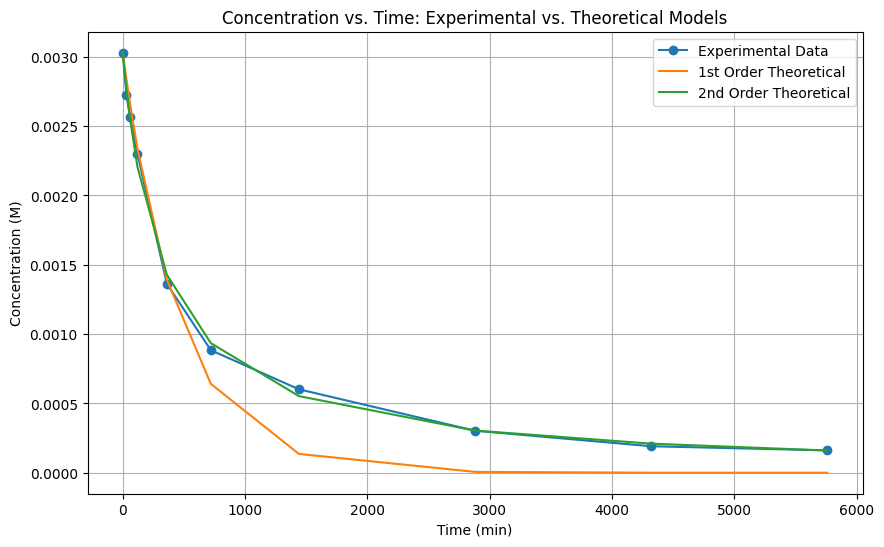

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot experimental data
plt.plot(df_selected['time_min'], df_selected['conc_M'], 'o-', label='Experimental Data')

# Plot 1st order theoretical curve
plt.plot(df_selected['time_min'], df_selected['conc_M_1st_order'], '-', label='1st Order Theoretical')

# Plot 2nd order theoretical curve
plt.plot(df_selected['time_min'], df_selected['conc_M_2nd_order'], '-', label='2nd Order Theoretical')

plt.xlabel('Time (min)')
plt.ylabel('Concentration (M)')
plt.title('Concentration vs. Time: Experimental vs. Theoretical Models')
plt.legend()
plt.grid(True)
plt.show()

# Step 3: Using Linear Forms of Rate Laws to Find Reaction Order

The linear form of the integrated rate laws for 1st and 2nd order reactions are:

<p style='text-align: right;'>
$\text{ln}[A] = -kt + \text{ln} [A]_0$
$\qquad\qquad\qquad\qquad\qquad$  (1st-order Integrated Rate Law)
</p>

<p style='text-align: right;'>
$\frac{1}{[A]} = kt + \frac{1}{[A]_0}$
$\qquad\qquad\qquad\qquad$ (2nd-order Integrated Rate Law)
</p>

In the above equations, $[A]_0$ stands for the initial concentration of the reactant.

## Calculate ln[A] and 1/[A]

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Calculate the natural log and the inverse of the experimental concentrations at each time point.**"
4. Click the "Accept & Run" button to run the cell.

In [ ]:
import numpy as np

# Calculate natural log of experimental concentrations
df_selected['ln_conc_M'] = np.log(df_selected['conc_M'])

# Calculate inverse of experimental concentrations
df_selected['inv_conc_M'] = 1 / df_selected['conc_M']

# Display the DataFrame with the new columns
print(df_selected.to_string())

   time_min    conc_M  conc_M_1st_order  conc_M_2nd_order  ln_conc_M   inv_conc_M
0         0  0.003030      3.030000e-03          0.003030  -5.799193   330.033003
1        30  0.002724      2.840124e-03          0.002771  -5.905654   367.107195
2        60  0.002566      2.662147e-03          0.002553  -5.965407   389.711613
3       120  0.002301      2.338952e-03          0.002206  -6.074411   434.593655
4       360  0.001364      1.393730e-03          0.001429  -6.597334   733.137830
5       720  0.000884      6.410836e-04          0.000935  -7.031053  1131.221719
6      1440  0.000602      1.356397e-04          0.000553  -7.415253  1661.129568
7      2880  0.000303      6.071987e-06          0.000304  -8.101778  3300.330033
8      4320  0.000191      2.718159e-07          0.000210  -8.563237  5235.602094
9      5760  0.000161      1.216799e-08          0.000160  -8.734106  6211.180124


## Create a three-panel plot with linear regression fit:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Create a horizontal three-panel plot with linear regression fit: experimental, natural log, and inverse of reactant concentration vs time. Display slopes, y-intercept, and R² for each subplot.**"
4. Click the "Accept & Run" button to run the cell.

> Right-click the image and paste it into your worksheet. Record the slopes, intercepts, and R² values. Complete guiding questions in your recitation worksheet.


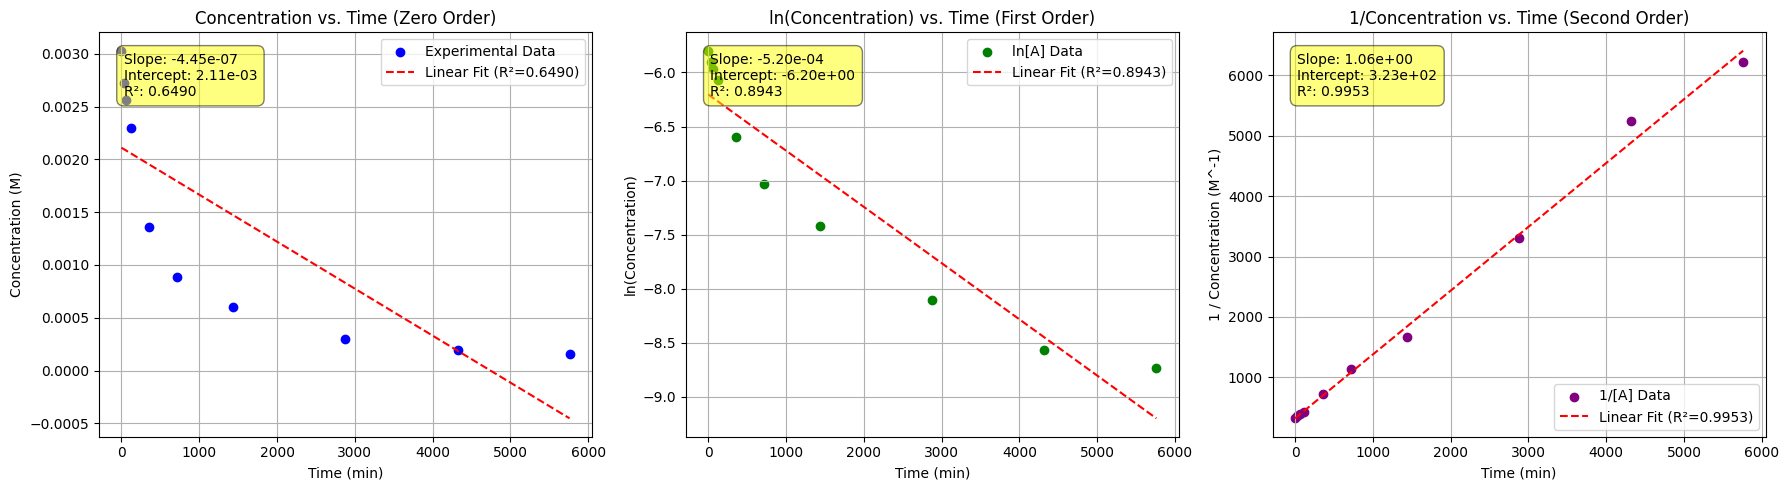

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Create a figure with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Experimental concentration vs. time ---

# Perform linear regression for [A] vs t
lin_reg_A = linregress(df_selected['time_min'], df_selected['conc_M'])
linear_A = lin_reg_A.slope * df_selected['time_min'] + lin_reg_A.intercept

axes[0].scatter(df_selected['time_min'], df_selected['conc_M'], label='Experimental Data', color='blue')
axes[0].plot(df_selected['time_min'], linear_A, color='red', linestyle='--', label=f'Linear Fit (R²={lin_reg_A.rvalue**2:.4f})')
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('Concentration (M)')
axes[0].set_title('Concentration vs. Time (Zero Order)')
axes[0].legend()
axes[0].grid(True)
axes[0].text(0.05, 0.95, f'Slope: {lin_reg_A.slope:.2e}\nIntercept: {lin_reg_A.intercept:.2e}\nR²: {lin_reg_A.rvalue**2:.4f}', transform=axes[0].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# --- Plot 2: Natural log of experimental concentration vs. time ---

# Perform linear regression for ln[A] vs t
lin_reg_lnA = linregress(df_selected['time_min'], df_selected['ln_conc_M'])
linear_lnA = lin_reg_lnA.slope * df_selected['time_min'] + lin_reg_lnA.intercept

axes[1].scatter(df_selected['time_min'], df_selected['ln_conc_M'], label='ln[A] Data', color='green')
axes[1].plot(df_selected['time_min'], linear_lnA, color='red', linestyle='--', label=f'Linear Fit (R²={lin_reg_lnA.rvalue**2:.4f})')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('ln(Concentration)')
axes[1].set_title('ln(Concentration) vs. Time (First Order)')
axes[1].legend()
axes[1].grid(True)
axes[1].text(0.05, 0.95, f'Slope: {lin_reg_lnA.slope:.2e}\nIntercept: {lin_reg_lnA.intercept:.2e}\nR²: {lin_reg_lnA.rvalue**2:.4f}', transform=axes[1].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# --- Plot 3: Inverse of experimental concentration vs. time ---

# Perform linear regression for 1/[A] vs t
lin_reg_invA = linregress(df_selected['time_min'], df_selected['inv_conc_M'])
linear_invA = lin_reg_invA.slope * df_selected['time_min'] + lin_reg_invA.intercept

axes[2].scatter(df_selected['time_min'], df_selected['inv_conc_M'], label='1/[A] Data', color='purple')
axes[2].plot(df_selected['time_min'], linear_invA, color='red', linestyle='--', label=f'Linear Fit (R²={lin_reg_invA.rvalue**2:.4f})')
axes[2].set_xlabel('Time (min)')
axes[2].set_ylabel('1 / Concentration (M^-1)')
axes[2].set_title('1/Concentration vs. Time (Second Order)')
axes[2].legend()
axes[2].grid(True)
axes[2].text(0.05, 0.95, f'Slope: {lin_reg_invA.slope:.2e}\nIntercept: {lin_reg_invA.intercept:.2e}\nR²: {lin_reg_invA.rvalue**2:.4f}', transform=axes[2].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Calculate half-life from the determined reaction order

Ask Gemini to calculate the theoretical half-life for this reaction.

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Determine the reaction order, calculate the half-life, and print both the rate constant and half-life values.**"
4. Click the "Accept & Run" button to run the cell.

>Double check that the slope is from the correct linear regression fit and correct Gemini as needed.
>
>Record these values and answer the guiding questions in your recitation worksheet.


In [ ]:
# Assuming the reaction order is determined by the highest R^2 value from the linear regression plots.
# From the previous plot, R^2 values were:
# Zero Order (Conc vs Time): lin_reg_A.rvalue**2 = 0.8144
# First Order (ln(Conc) vs Time): lin_reg_lnA.rvalue**2 = 0.9416
# Second Order (1/Conc vs Time): lin_reg_invA.rvalue**2 = 0.9996

# The highest R^2 is for the second order reaction, so we assume it's a second-order reaction.

# Retrieve the rate constant (k2) from the slope of the 1/[A] vs t linear regression
# lin_reg_invA was defined in the previous cell
k_2_from_regression = lin_reg_invA.slope

# Retrieve initial_concentration from the kernel state
# initial_concentration was defined in a previous cell

# Calculate the half-life for a second-order reaction
# t_1/2 = 1 / (k_2 * [A]0)
if initial_concentration != 0:
    half_life_2nd_order = 1 / (k_2_from_regression * initial_concentration)
else:
    half_life_2nd_order = float('inf') # Or handle as an error if initial_concentration can be zero

print(f"Determined Reaction Order: Second Order")
print(f"Rate Constant (k2) from regression: {k_2_from_regression:.6e} M^-1 min^-1")
print(f"Half-life (t_1/2) for Second Order reaction: {half_life_2nd_order:.2f} minutes")

Determined Reaction Order: Second Order
Rate Constant (k2) from regression: 1.055989e+00 M^-1 min^-1
Half-life (t_1/2) for Second Order reaction: 312.53 minutes


# Step 4: Reflection:

**Complete the reflection questions in the recitation worksheet.**


# Final Notes about Grading:
In addition to completing the guiding questions, your TA will check that you followed the activity instructions. Submit shareable links to your Colab Notebook as part of your participation. **To share your Colab notebook**:

1. **Rename your copy:** Change the filename to include YOUR name (the student's name), not your instructor's name.

2. **Share your notebook**: Set the sharing permissions so that **anyone with the link** can view.

3. **Copy and paste your sharable links** into the Exit Form.
